In [1]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_titanic.csv to cleaned_titanic.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve

from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv("cleaned_titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [4]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [5]:
X = df[["Pclass","Sex","Age","Fare"]]

y = df["Survived"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 0.8044692737430168


In [11]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



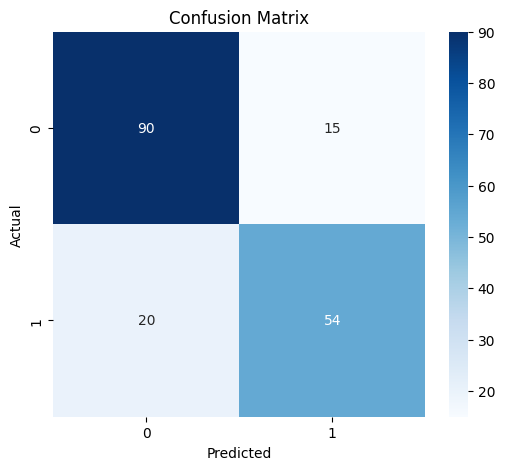

In [12]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

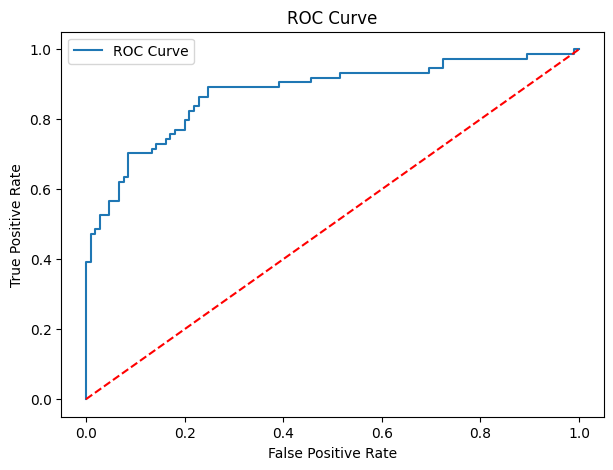

AUC Score: 0.875032175032175


In [13]:
y_prob = model.predict_proba(X_test)[:,1]

fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],"r--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score:",roc_auc_score(y_test,y_prob))

Logistic Regression successfully classified passenger survival using passenger class, gender, age, and fare. The model achieved satisfactory accuracy and demonstrated that gender and passenger class are important predictors of survival. Although the model performs well, additional features and advanced algorithms could further improve prediction accuracy.